# PINN-MPC v6 Alpha LOAD-ONLY: PID vs CEM vs MPPI

This notebook loads a previously trained v6 alpha-state PINN dynamics checkpoint and uses it for MPC.

Important:
- The PINN is never retrained in this notebook.
- The only optional optimization is PID gain tuning with Optuna.
- Controllers compared: Optuna-tuned PID, Random Shooting MPC, CEM MPC, MPPI MPC.

Expected checkpoint:
`/content/drive/MyDrive/PINN_MODEL_ONLY_v1/pinn_dynamics_c172_2d_v6_alpha.pt`

## 0. Install & Imports

In [12]:
!pip install jsbsim optuna -q
print('Install complete')

Install complete


In [13]:
import os, json, time, random, warnings
warnings.filterwarnings('ignore')

import jsbsim
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import optuna

try:
    from google.colab import drive
    drive.mount('/content/drive')
    DEFAULT_MODEL_PATH = '/content/drive/MyDrive/PINN_MODEL_ONLY_v1/pinn_dynamics_c172_2d_v6_alpha.pt'
    DEFAULT_SAVE_DIR = '/content/drive/MyDrive/PINN_MPC_V6_ALPHA_COMPARISON'
except Exception:
    DEFAULT_MODEL_PATH = './PINN_MODEL_ONLY_v1/pinn_dynamics_c172_2d_v6_alpha.pt'
    DEFAULT_SAVE_DIR = './PINN_MPC_V6_ALPHA_COMPARISON'

MODEL_PATH = DEFAULT_MODEL_PATH
SAVE_DIR = DEFAULT_SAVE_DIR
os.makedirs(SAVE_DIR, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
print('MODEL_PATH:', MODEL_PATH)
print('SAVE_DIR:', SAVE_DIR)

SEED = 123
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cpu
MODEL_PATH: /content/drive/MyDrive/PINN_MODEL_ONLY_v1/pinn_dynamics_c172_2d_v6_alpha.pt
SAVE_DIR: /content/drive/MyDrive/PINN_MPC_V6_ALPHA_COMPARISON


## 1. Configuration

In [14]:
FAST_MODE = True

# PINN is loaded only. No PINN data collection or training is performed here.
PINN_LOAD_ONLY = True

# This tunes only PID gains, not the PINN model.
# Set False to use DEFAULT_PID_PARAMS and skip Optuna entirely.
TUNE_PID_WITH_OPTUNA = True
DEFAULT_PID_PARAMS = {
    'kp_alt': 0.0008,
    'kp': 0.8,
    'ki': 0.02,
    'kd': 0.08,
    'kq': 0.2,
}

INIT_ALT = 3000.0
TARGET_ALT = 5000.0
THROTTLE = 0.85
DT = 0.02

STATE_COLS = ['h', 'V', 'theta', 'q', 'alpha']
INPUT_COLS = ['elevator', 'prev_elevator', 'delevator']
FEAT_COLS = STATE_COLS + INPUT_COLS
TGT_COLS = ['dh', 'dV', 'dtheta', 'dq', 'dalpha']

MAX_STEPS = 2500 if FAST_MODE else 4000
REACHED_BAND_FT = 100.0
REACHED_HOLD_STEPS = 60

PITCH_LIMIT_DEG = 25.0
PITCH_ABORT_DEG = 65.0
ALPHA_LIMIT_DEG = 18.0
ALT_MIN_FT = 500.0
ALT_MAX_FT = 12000.0

ELEV_LIMIT = 0.45
DELTA_ELEV_LIMIT = 0.08

if FAST_MODE:
    PID_TRIALS = 25
    MPC_HORIZON = 15
    MPC_SAMPLES = 24
    N_TEST_CASES = 2
else:
    PID_TRIALS = 70
    MPC_HORIZON = 45
    MPC_SAMPLES = 160
    N_TEST_CASES = 10

CONFIG = dict(
    FAST_MODE=FAST_MODE,
    PINN_LOAD_ONLY=PINN_LOAD_ONLY,
    TUNE_PID_WITH_OPTUNA=TUNE_PID_WITH_OPTUNA,
    INIT_ALT=INIT_ALT,
    TARGET_ALT=TARGET_ALT,
    THROTTLE=THROTTLE,
    DT=DT,
    MAX_STEPS=MAX_STEPS,
    PID_TRIALS=PID_TRIALS,
    MPC_HORIZON=MPC_HORIZON,
    MPC_SAMPLES=MPC_SAMPLES,
    N_TEST_CASES=N_TEST_CASES,
    ELEV_LIMIT=ELEV_LIMIT,
    DELTA_ELEV_LIMIT=DELTA_ELEV_LIMIT,
)
print(json.dumps(CONFIG, indent=2))

{
  "FAST_MODE": true,
  "PINN_LOAD_ONLY": true,
  "TUNE_PID_WITH_OPTUNA": true,
  "INIT_ALT": 3000.0,
  "TARGET_ALT": 5000.0,
  "THROTTLE": 0.85,
  "DT": 0.02,
  "MAX_STEPS": 2500,
  "PID_TRIALS": 25,
  "MPC_HORIZON": 15,
  "MPC_SAMPLES": 24,
  "N_TEST_CASES": 2,
  "ELEV_LIMIT": 0.45,
  "DELTA_ELEV_LIMIT": 0.08
}


## 2. JSBSim Plant Helpers

In [15]:
def get_prop(fdm, name, default=0.0):
    try:
        return float(fdm[name])
    except Exception:
        return float(default)


def make_fdm(init_alt=INIT_ALT, init_speed=100.0, init_pitch=0.0):
    fdm = jsbsim.FGFDMExec(None, None)
    fdm.set_debug_level(0)
    fdm.load_model('c172p')
    fdm['ic/h-sl-ft'] = float(init_alt)
    fdm['ic/vt-kts'] = float(init_speed)
    fdm['ic/theta-deg'] = float(init_pitch)
    fdm['ic/psi-true-deg'] = 0.0
    fdm.run_ic()
    fdm['propulsion/engine/set-running'] = 1
    fdm['fcs/throttle-cmd-norm'] = THROTTLE
    return fdm


def read_state(fdm):
    return np.array([
        get_prop(fdm, 'position/h-sl-ft'),
        get_prop(fdm, 'velocities/vt-fps'),
        get_prop(fdm, 'attitude/theta-rad'),
        get_prop(fdm, 'velocities/q-rad_sec'),
        get_prop(fdm, 'aero/alpha-rad', 0.0),
    ], dtype=np.float32)


def apply_control(fdm, elevator):
    fdm['fcs/elevator-cmd-norm'] = float(np.clip(elevator, -1.0, 1.0))
    fdm.run()


print('JSBSim helpers ready')

JSBSim helpers ready


## 3. Load Saved v6 Alpha PINN Checkpoint

This section reconstructs the network architecture and loads `model_state` from disk. It does not train, fit, optimize, or update the PINN parameters.

In [16]:
class PhysicsPINN(nn.Module):
    def __init__(self, hidden_dim=192, n_layers=4, stats=None):
        super().__init__()
        input_dim = len(FEAT_COLS)
        output_dim = len(TGT_COLS)
        self.register_buffer('Xm', stats['Xm'].clone() if stats else torch.zeros(input_dim))
        self.register_buffer('Xs', stats['Xs'].clone() if stats else torch.ones(input_dim))
        self.register_buffer('Ym', stats['Ym'].clone() if stats else torch.zeros(output_dim))
        self.register_buffer('Ys', stats['Ys'].clone() if stats else torch.ones(output_dim))

        layers = [nn.Linear(input_dim, hidden_dim), nn.SiLU()]
        for _ in range(n_layers - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.SiLU()]
        layers.append(nn.Linear(hidden_dim, output_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x_norm):
        return self.net(x_norm)

    def denorm_delta(self, d_norm, add_mean=True):
        if add_mean:
            return d_norm * self.Ys + self.Ym
        return d_norm * self.Ys


assert PINN_LOAD_ONLY is True
assert os.path.exists(MODEL_PATH), f'Missing trained PINN checkpoint: {MODEL_PATH}'

checkpoint = torch.load(MODEL_PATH, map_location=device)
stats = {k: v.to(device) for k, v in checkpoint['stats'].items()}
params = checkpoint['best_params']

model = PhysicsPINN(
    hidden_dim=params.get('hidden_dim', 192),
    n_layers=params.get('n_layers', 4),
    stats=stats,
).to(device)
model.load_state_dict(checkpoint['model_state'])
model.eval()
for p in model.parameters():
    p.requires_grad_(False)

print('Loaded saved v6 alpha PINN checkpoint')
print('PINN parameters frozen:', not any(p.requires_grad for p in model.parameters()))
print('best_params:', params)
print('feature_cols:', checkpoint.get('feature_cols'))
print('target_cols:', checkpoint.get('target_cols'))
print('auto_summary:', json.dumps(checkpoint.get('auto_summary', {}), indent=2))

Loaded saved v6 alpha PINN checkpoint
PINN parameters frozen: True
best_params: {'hidden_dim': 192, 'n_layers': 4, 'lr': 0.0005, 'lam_physics': 0.1, 'lam_smooth': 0.0005, 'lam_rollout': 0.1, 'target_weights': [1.0, 1.0, 2.0, 8.0, 2.0], 'epochs': 340}
feature_cols: ['h', 'V', 'theta', 'q', 'alpha', 'elevator', 'prev_elevator', 'delevator']
target_cols: ['dh', 'dV', 'dtheta', 'dq', 'dalpha']
auto_summary: {
  "best_cycle": 0,
  "best_rollout_score_val": 0.3200063483543797,
  "best_h_rmse_mean_val": 0.37132277619093657,
  "best_theta_rmse_mean_val": 0.0007993993785930797,
  "best_q_rmse_mean_val": 0.0018216835087514482,
  "final_rollout_score_test": 0.1880706141043144,
  "final_h_rmse_mean_test": 0.21852892497554421,
  "final_theta_rmse_mean_test": 0.0006437486226786859,
  "final_q_rmse_mean_test": 0.0007485623646061867,
  "test_targets_met": true,
  "auto_cycles_run": 0,
  "auto_restart_policy": "restart_each_cycle_from_best_rollout_checkpoint"
}


## 4. PINN Rollout for Control

In [17]:
@torch.no_grad()
def pinn_step(model, state, elevator, prev_elevator):
    elevator = float(np.clip(elevator, -ELEV_LIMIT, ELEV_LIMIT))
    prev_elevator = float(np.clip(prev_elevator, -ELEV_LIMIT, ELEV_LIMIT))
    delevator = elevator - prev_elevator
    x = np.array([state[0], state[1], state[2], state[3], state[4],
                  elevator, prev_elevator, delevator], dtype=np.float32)
    xt = torch.tensor(x, dtype=torch.float32, device=device).unsqueeze(0)
    xn = (xt - model.Xm) / model.Xs
    dn = model(xn)
    delta = model.denorm_delta(dn, add_mean=True).cpu().numpy()[0]
    return state + delta


@torch.no_grad()
def rollout_pinn_control(model, init_state, elevator_seq, prev_elevator):
    states = [np.asarray(init_state, dtype=np.float32).copy()]
    current = states[0].copy()
    prev = float(prev_elevator)
    applied = []
    for raw_elev in elevator_seq:
        elev = float(np.clip(raw_elev, prev - DELTA_ELEV_LIMIT, prev + DELTA_ELEV_LIMIT))
        elev = float(np.clip(elev, -ELEV_LIMIT, ELEV_LIMIT))
        current = pinn_step(model, current, elev, prev)
        states.append(current.copy())
        applied.append(elev)
        prev = elev
    return np.asarray(states), np.asarray(applied, dtype=np.float32)


print('PINN control rollout ready')

PINN control rollout ready


## 5. PID Baseline Tuning

In [18]:
class TunedPID:
    def __init__(self, params):
        self.kp_alt = params['kp_alt']
        self.kp = params['kp']
        self.ki = params['ki']
        self.kd = params['kd']
        self.kq = params.get('kq', 0.0)
        self.integral = 0.0
        self.prev_err = 0.0
        self.prev_elev = 0.0
        self.ILIM = 8.0

    def reset(self):
        self.integral = 0.0
        self.prev_err = 0.0
        self.prev_elev = 0.0

    def update(self, state, target_alt):
        h, V, theta, q, alpha = state
        theta_cmd = np.clip((target_alt - h) * self.kp_alt, -0.25, 0.25)
        err = theta_cmd - theta
        self.integral = np.clip(self.integral + err * DT, -self.ILIM, self.ILIM)
        deriv = (err - self.prev_err) / DT
        self.prev_err = err

        raw = self.kp * err + self.ki * self.integral + self.kd * deriv - self.kq * q
        elev = np.clip(raw, self.prev_elev - DELTA_ELEV_LIMIT, self.prev_elev + DELTA_ELEV_LIMIT)
        elev = np.clip(elev, -ELEV_LIMIT, ELEV_LIMIT)
        self.prev_elev = float(elev)
        return float(elev), {'theta_cmd': float(theta_cmd), 'cost': abs(target_alt - h)}


def eval_pid_params(params, init_alt=INIT_ALT, target_alt=TARGET_ALT, n_steps=1200):
    controller = TunedPID(params)
    fdm = make_fdm(init_alt=init_alt)
    alts, pitches, qs, alphas, elevs = [], [], [], [], []

    for _ in range(n_steps):
        state = read_state(fdm)
        h, V, theta, q, alpha = state
        if h < ALT_MIN_FT or h > ALT_MAX_FT or abs(np.degrees(theta)) > PITCH_ABORT_DEG:
            return 1e8
        elev, _ = controller.update(state, target_alt)
        apply_control(fdm, elev)
        alts.append(h)
        pitches.append(np.degrees(theta))
        qs.append(np.degrees(q))
        alphas.append(np.degrees(alpha))
        elevs.append(elev)

    alts = np.asarray(alts)
    pitches = np.asarray(pitches)
    qs = np.asarray(qs)
    alphas = np.asarray(alphas)
    elevs = np.asarray(elevs)

    rmse = np.sqrt(np.mean((alts - target_alt) ** 2))
    pitch_pen = 8.0 * np.mean(np.maximum(0.0, np.abs(pitches) - PITCH_LIMIT_DEG) ** 2)
    alpha_pen = 4.0 * np.mean(np.maximum(0.0, np.abs(alphas) - ALPHA_LIMIT_DEG) ** 2)
    q_pen = 0.03 * np.mean(qs ** 2)
    effort = 20.0 * np.mean(np.diff(elevs, prepend=elevs[0]) ** 2)
    return float(rmse + pitch_pen + alpha_pen + q_pen + effort)


def pid_objective(trial):
    params = {
        'kp_alt': trial.suggest_float('kp_alt', 0.00008, 0.0025, log=True),
        'kp': trial.suggest_float('kp', 0.05, 2.5, log=True),
        'ki': trial.suggest_float('ki', 0.0005, 0.15, log=True),
        'kd': trial.suggest_float('kd', 0.005, 1.5, log=True),
        'kq': trial.suggest_float('kq', 0.0, 1.5),
    }
    return eval_pid_params(params)


if TUNE_PID_WITH_OPTUNA:
    print(f'Tuning PID gains with {PID_TRIALS} Optuna trials. This does not retrain the PINN.')
    pid_study = optuna.create_study(direction='minimize')
    pid_study.optimize(pid_objective, n_trials=PID_TRIALS, show_progress_bar=True)
    PID_PARAMS = pid_study.best_params
    print('Best PID params:', PID_PARAMS)
    print('Best PID objective:', pid_study.best_value)
else:
    PID_PARAMS = dict(DEFAULT_PID_PARAMS)
    print('Using DEFAULT_PID_PARAMS:', PID_PARAMS)

[I 2026-04-29 09:43:32,224] A new study created in memory with name: no-name-50f042c0-aac9-4a9c-9114-5960c4c654c8


Tuning PID gains with 25 Optuna trials. This does not retrain the PINN.


  0%|          | 0/25 [00:00<?, ?it/s]

[I 2026-04-29 09:43:32,397] Trial 0 finished with value: 1893.2934736818295 and parameters: {'kp_alt': 0.0005636133252886254, 'kp': 0.09256037218343313, 'ki': 0.001046068568355057, 'kd': 1.1350001275130275, 'kq': 0.23287817040131048}. Best is trial 0 with value: 1893.2934736818295.
[I 2026-04-29 09:43:32,564] Trial 1 finished with value: 3410.2372192402745 and parameters: {'kp_alt': 0.00029311514802020096, 'kp': 1.6610019159692475, 'ki': 0.00344957939079971, 'kd': 0.9877163225561474, 'kq': 0.6185150938784318}. Best is trial 0 with value: 1893.2934736818295.
[I 2026-04-29 09:43:32,723] Trial 2 finished with value: 1888.8610869753131 and parameters: {'kp_alt': 0.0021978574922058604, 'kp': 0.08319447177505973, 'ki': 0.001452692999276481, 'kd': 0.021550223772144092, 'kq': 0.862231201375421}. Best is trial 2 with value: 1888.8610869753131.
[I 2026-04-29 09:43:32,840] Trial 3 finished with value: 2304.000121841518 and parameters: {'kp_alt': 0.0006407849782933244, 'kp': 0.6882741778272076, 'k

## 6. MPC Cost Function

In [19]:
def mpc_cost(predicted, target_alt, elev_seq):
    h = predicted[:, 0]
    V = predicted[:, 1]
    theta = predicted[:, 2]
    q = predicted[:, 3]
    alpha = predicted[:, 4]
    elev_seq = np.asarray(elev_seq)

    alt_err = (h - target_alt) / max(target_alt, 1.0)
    c_alt = 10.0 * np.mean(alt_err ** 2)
    c_terminal = 18.0 * (alt_err[-1] ** 2)

    theta_deg = np.degrees(theta)
    q_deg = np.degrees(q)
    alpha_deg = np.degrees(alpha)

    c_pitch = 0.04 * np.mean(theta_deg ** 2)
    c_pitch_limit = 25.0 * np.mean(np.maximum(0.0, np.abs(theta_deg) - PITCH_LIMIT_DEG) ** 2)
    c_alpha_limit = 16.0 * np.mean(np.maximum(0.0, np.abs(alpha_deg) - ALPHA_LIMIT_DEG) ** 2)
    c_q = 0.05 * np.mean(q_deg ** 2)
    c_speed = 0.0002 * np.mean(np.maximum(0.0, 55.0 - V) ** 2)
    c_effort = 0.02 * np.mean(elev_seq ** 2)
    c_smooth = 0.12 * np.mean(np.diff(elev_seq, prepend=elev_seq[0]) ** 2)

    unsafe = np.any((h < ALT_MIN_FT) | (h > ALT_MAX_FT) | (np.abs(theta_deg) > PITCH_ABORT_DEG))
    c_abort = 1e3 if unsafe else 0.0

    return float(c_alt + c_terminal + c_pitch + c_pitch_limit + c_alpha_limit + c_q + c_speed + c_effort + c_smooth + c_abort)

## 7. PINN-MPC Controllers

In [20]:
class RandomShootingMPC:
    def __init__(self, horizon=MPC_HORIZON, n_samples=MPC_SAMPLES, sigma=0.18):
        self.horizon = horizon
        self.n_samples = n_samples
        self.sigma = sigma
        self.U = np.zeros(horizon, dtype=np.float32)
        self.prev_elev = 0.0

    def reset(self):
        self.U[:] = 0.0
        self.prev_elev = 0.0

    def sample_sequences(self):
        noise = np.random.normal(0.0, self.sigma, size=(self.n_samples, self.horizon))
        return np.clip(self.U[None, :] + noise, -ELEV_LIMIT, ELEV_LIMIT)

    def update(self, state, target_alt):
        seqs = self.sample_sequences()
        costs = np.empty(self.n_samples)
        applied_cache = []
        for i, seq in enumerate(seqs):
            pred, applied = rollout_pinn_control(model, state, seq, self.prev_elev)
            costs[i] = mpc_cost(pred, target_alt, applied)
            applied_cache.append(applied)

        best_idx = int(np.argmin(costs))
        best_applied = applied_cache[best_idx]
        action = float(best_applied[0])
        self.prev_elev = action
        self.U = np.append(best_applied[1:], best_applied[-1]).astype(np.float32)
        return action, {'cost': float(costs[best_idx]), 'best_cost': float(costs[best_idx])}


class CEMMPC:
    """
    Cross-Entropy Method MPC.

    CEM samples candidate control sequences around a nominal mean sequence,
    keeps only the elite low-cost samples, then updates the mean and standard
    deviation from those elites. It is a strong sampling-MPC baseline, but the
    hard elite selection can make updates less smooth than MPPI.
    """
    def __init__(self, horizon=MPC_HORIZON, n_samples=MPC_SAMPLES,
                 elite_frac=0.15, init_sigma=0.20, min_sigma=0.03,
                 momentum=0.25, n_iters=2):
        self.horizon = horizon
        self.n_samples = n_samples
        self.elite_frac = elite_frac
        self.init_sigma = init_sigma
        self.min_sigma = min_sigma
        self.momentum = momentum
        self.n_iters = n_iters
        self.U = np.zeros(horizon, dtype=np.float32)
        self.S = np.ones(horizon, dtype=np.float32) * init_sigma
        self.prev_elev = 0.0

    def reset(self):
        self.U[:] = 0.0
        self.S[:] = self.init_sigma
        self.prev_elev = 0.0

    def update(self, state, target_alt):
        mean = self.U.copy()
        std = self.S.copy()
        best_cost = np.inf
        best_applied = None

        for _ in range(self.n_iters):
            raw = np.random.normal(mean[None, :], std[None, :],
                                   size=(self.n_samples, self.horizon))
            seqs = np.clip(raw, -ELEV_LIMIT, ELEV_LIMIT)

            costs = np.empty(self.n_samples)
            applied_cache = []
            for i, seq in enumerate(seqs):
                pred, applied = rollout_pinn_control(model, state, seq, self.prev_elev)
                costs[i] = mpc_cost(pred, target_alt, applied)
                applied_cache.append(applied)

            elite_n = max(2, int(self.elite_frac * self.n_samples))
            elite_idx = np.argsort(costs)[:elite_n]
            elite = np.asarray([applied_cache[i] for i in elite_idx])

            elite_mean = elite.mean(axis=0)
            elite_std = elite.std(axis=0) + 1e-6
            mean = self.momentum * mean + (1.0 - self.momentum) * elite_mean
            std = self.momentum * std + (1.0 - self.momentum) * elite_std
            std = np.clip(std, self.min_sigma, self.init_sigma)

            if costs[elite_idx[0]] < best_cost:
                best_cost = float(costs[elite_idx[0]])
                best_applied = applied_cache[int(elite_idx[0])]

        self.U = np.clip(mean, -ELEV_LIMIT, ELEV_LIMIT).astype(np.float32)
        self.S = std.astype(np.float32)

        action = float(best_applied[0] if best_applied is not None else self.U[0])
        action = float(np.clip(action, self.prev_elev - DELTA_ELEV_LIMIT, self.prev_elev + DELTA_ELEV_LIMIT))
        action = float(np.clip(action, -ELEV_LIMIT, ELEV_LIMIT))
        self.prev_elev = action

        self.U = np.append(self.U[1:], self.U[-1]).astype(np.float32)
        self.S = np.append(self.S[1:], self.S[-1]).astype(np.float32)
        return action, {'cost': best_cost, 'best_cost': best_cost}


class MPPIMPC:
    """
    Model Predictive Path Integral MPC.

    MPPI uses all samples with soft exponential weights. Compared with CEM,
    this often gives smoother updates because there is no hard top-k cutoff.
    """
    def __init__(self, horizon=MPC_HORIZON, n_samples=MPC_SAMPLES, sigma=0.18, lam=0.08):
        self.horizon = horizon
        self.n_samples = n_samples
        self.sigma = sigma
        self.lam = lam
        self.U = np.zeros(horizon, dtype=np.float32)
        self.prev_elev = 0.0

    def reset(self):
        self.U[:] = 0.0
        self.prev_elev = 0.0

    def update(self, state, target_alt):
        eps = np.random.normal(0.0, self.sigma, size=(self.n_samples, self.horizon))
        seqs = np.clip(self.U[None, :] + eps, -ELEV_LIMIT, ELEV_LIMIT)

        costs = np.empty(self.n_samples)
        applied_cache = []
        for i, seq in enumerate(seqs):
            pred, applied = rollout_pinn_control(model, state, seq, self.prev_elev)
            costs[i] = mpc_cost(pred, target_alt, applied)
            applied_cache.append(applied)

        beta = costs.min()
        weights = np.exp(-(costs - beta) / max(self.lam, 1e-6))
        weights = weights / (weights.sum() + 1e-9)

        weighted_seq = np.sum(weights[:, None] * np.asarray(applied_cache), axis=0)
        self.U = np.clip(weighted_seq, -ELEV_LIMIT, ELEV_LIMIT).astype(np.float32)
        action = float(self.U[0])
        action = float(np.clip(action, self.prev_elev - DELTA_ELEV_LIMIT, self.prev_elev + DELTA_ELEV_LIMIT))
        action = float(np.clip(action, -ELEV_LIMIT, ELEV_LIMIT))
        self.prev_elev = action
        self.U = np.append(self.U[1:], self.U[-1]).astype(np.float32)
        return action, {'cost': float(np.sum(weights * costs)), 'best_cost': float(beta)}


print('MPC controllers ready')
print('  RandomShootingMPC: simple sampling baseline')
print('  CEMMPC           : elite-sample sampling MPC')
print('  MPPIMPC          : soft-weighted sampling MPC')

MPC controllers ready
  RandomShootingMPC: simple sampling baseline
  CEMMPC           : elite-sample sampling MPC
  MPPIMPC          : soft-weighted sampling MPC


## 8. Simulation Runner

In [21]:
def run_sim(controller, name, init_alt=INIT_ALT, init_speed=100.0, init_pitch=0.0, target_alt=TARGET_ALT):
    fdm = make_fdm(init_alt=init_alt, init_speed=init_speed, init_pitch=init_pitch)
    controller.reset()
    hold_count = 0
    abort_reason = None

    log = {k: [] for k in [
        'time', 'altitude', 'velocity', 'pitch_deg', 'pitch_rate_deg_s',
        'alpha_deg', 'elevator', 'theta_cmd_deg', 'cost', 'comp_ms'
    ]}

    for step in range(MAX_STEPS):
        state = read_state(fdm)
        h, V, theta, q, alpha = state

        if h < ALT_MIN_FT:
            abort_reason = f'LOW_ALT {h:.1f} ft'
            break
        if h > ALT_MAX_FT:
            abort_reason = f'HIGH_ALT {h:.1f} ft'
            break
        if abs(np.degrees(theta)) > PITCH_ABORT_DEG:
            abort_reason = f'PITCH_ABORT {np.degrees(theta):.1f} deg'
            break

        t0 = time.perf_counter()
        elev, info = controller.update(state, target_alt)
        comp_ms = (time.perf_counter() - t0) * 1000.0
        apply_control(fdm, elev)

        log['time'].append(step * DT)
        log['altitude'].append(float(h))
        log['velocity'].append(float(V))
        log['pitch_deg'].append(float(np.degrees(theta)))
        log['pitch_rate_deg_s'].append(float(np.degrees(q)))
        log['alpha_deg'].append(float(np.degrees(alpha)))
        log['elevator'].append(float(elev))
        log['theta_cmd_deg'].append(float(np.degrees(info.get('theta_cmd', np.nan))))
        log['cost'].append(float(info.get('cost', np.nan)))
        log['comp_ms'].append(float(comp_ms))

        if abs(h - target_alt) < REACHED_BAND_FT:
            hold_count += 1
            if hold_count >= REACHED_HOLD_STEPS:
                break
        else:
            hold_count = 0

    log['name'] = name
    log['abort_reason'] = abort_reason
    log['init_alt'] = init_alt
    log['init_speed'] = init_speed
    log['init_pitch'] = init_pitch
    log['target_alt'] = target_alt
    return log


def compute_metrics(log):
    alt = np.asarray(log['altitude'])
    pitch = np.asarray(log['pitch_deg'])
    q = np.asarray(log['pitch_rate_deg_s'])
    alpha = np.asarray(log['alpha_deg'])
    elev = np.asarray(log['elevator'])
    comp = np.asarray(log['comp_ms'])
    t = np.asarray(log['time'])
    target = log['target_alt']

    if len(alt) == 0:
        return {'Controller': log['name'], 'Abort': log['abort_reason'] or 'EMPTY'}

    reached = np.where(np.abs(alt - target) < REACHED_BAND_FT)[0]
    reach_time = float(t[reached[0]]) if len(reached) else np.nan
    tail = max(1, int(0.2 * len(alt)))

    return {
        'Controller': log['name'],
        'Init Alt': round(log['init_alt'], 1),
        'Target Alt': round(target, 1),
        'Reach Time (s)': round(reach_time, 2) if np.isfinite(reach_time) else np.nan,
        'Alt RMSE (ft)': round(float(np.sqrt(np.mean((alt - target) ** 2))), 2),
        'Final Error (ft)': round(float(alt[-1] - target), 2),
        'Tail MAE (ft)': round(float(np.mean(np.abs(alt[-tail:] - target))), 2),
        'Max Pitch (deg)': round(float(np.max(np.abs(pitch))), 2),
        'Max Alpha (deg)': round(float(np.max(np.abs(alpha))), 2),
        'Pitch Viol': int(np.sum(np.abs(pitch) > PITCH_LIMIT_DEG)),
        'Alpha Viol': int(np.sum(np.abs(alpha) > ALPHA_LIMIT_DEG)),
        'Pitch Rate RMS': round(float(np.sqrt(np.mean(q ** 2))), 3),
        'Elev RMS': round(float(np.sqrt(np.mean(elev ** 2))), 4),
        'Elev Smooth': round(float(np.mean(np.diff(elev, prepend=elev[0]) ** 2)), 6),
        'Mean Comp (ms)': round(float(np.mean(comp)), 2),
        'Max Comp (ms)': round(float(np.max(comp)), 2),
        'Steps': len(alt),
        'Abort': log['abort_reason'] or 'None',
    }


print('Simulation runner ready')

Simulation runner ready


## 9. Single Scenario Comparison

In [22]:
controllers = [
    TunedPID(PID_PARAMS),
    RandomShootingMPC(horizon=MPC_HORIZON, n_samples=MPC_SAMPLES, sigma=0.18),
    CEMMPC(horizon=MPC

           _HORIZON, n_samples=MPC_SAMPLES, elite_frac=0.15,
           init_sigma=0.20, min_sigma=0.03, momentum=0.25, n_iters=2),
    MPPIMPC(horizon=MPC_HORIZON, n_samples=MPC_SAMPLES, sigma=0.18, lam=0.08),
]

logs = []
for ctrl in controllers:
    name = ctrl.__class__.__name__
    print('Running:', name)
    logs.append(run_sim(ctrl, name, init_alt=INIT_ALT, init_speed=100.0, init_pitch=0.0, target_alt=TARGET_ALT))

metrics = pd.DataFrame([compute_metrics(log) for log in logs])
metrics.to_csv(os.path.join(SAVE_DIR, 'single_scenario_metrics.csv'), index=False)
metrics

Running: TunedPID
Running: RandomShootingMPC
Running: CEMMPC
Running: MPPIMPC


,Controller,Init Alt,Target Alt,Reach Time (s),Alt RMSE (ft),Final Error (ft),Tail MAE (ft),Max Pitch (deg),Max Alpha (deg),Pitch Viol,Alpha Viol,Pitch Rate RMS,Elev RMS,Elev Smooth,Mean Comp (ms),Max Comp (ms),Steps,Abort
0,TunedPID,3000.0,5000.0,NaN,2038.02,-2205.51,2260.35,27.68,8.61,343,0,8.015,0.1161,0.000010,0.20,12.21,2500,None
1,RandomShootingMPC,3000.0,5000.0,NaN,2056.63,-2174.60,2137.99,5.31,2.83,0,0,0.366,0.1140,0.005026,99.30,587.53,2500,None
2,CEMMPC,3000.0,5000.0,NaN,2057.82,-2174.53,2138.94,5.05,2.80,0,0,0.221,0.1017,0.001780,185.58,301.42,2500,None
3,MPPIMPC,3000.0,5000.0,NaN,2058.28,-2184.47,2145.23,5.91,2.73,0,0,0.338,0.1014,0.000349,92.51,160.07,2500,None


Saved: /content/drive/MyDrive/PINN_MPC_V6_ALPHA_COMPARISON/single_scenario_comparison.png


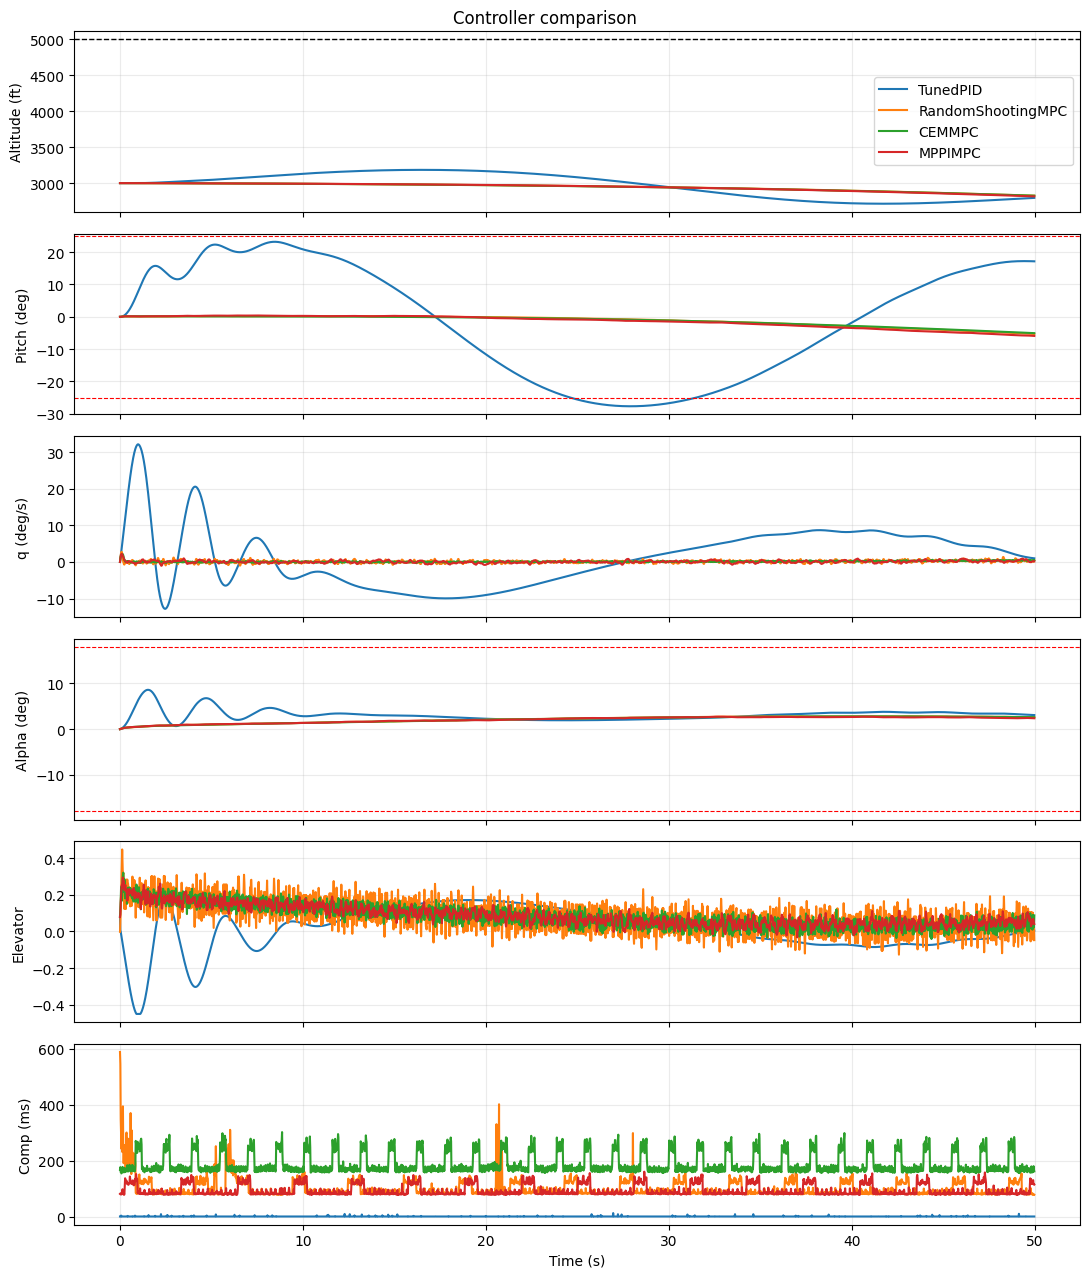

In [23]:
def plot_logs(logs, title='Controller comparison'):
    fig, axes = plt.subplots(6, 1, figsize=(11, 13), sharex=True)
    for log in logs:
        t = np.asarray(log['time'])
        label = log['name']
        axes[0].plot(t, log['altitude'], label=label)
        axes[1].plot(t, log['pitch_deg'], label=label)
        axes[2].plot(t, log['pitch_rate_deg_s'], label=label)
        axes[3].plot(t, log['alpha_deg'], label=label)
        axes[4].plot(t, log['elevator'], label=label)
        axes[5].plot(t, log['comp_ms'], label=label)

    axes[0].axhline(TARGET_ALT, color='k', ls='--', lw=1)
    axes[0].set_ylabel('Altitude (ft)')
    axes[1].axhline(PITCH_LIMIT_DEG, color='r', ls='--', lw=0.8)
    axes[1].axhline(-PITCH_LIMIT_DEG, color='r', ls='--', lw=0.8)
    axes[1].set_ylabel('Pitch (deg)')
    axes[2].set_ylabel('q (deg/s)')
    axes[3].axhline(ALPHA_LIMIT_DEG, color='r', ls='--', lw=0.8)
    axes[3].axhline(-ALPHA_LIMIT_DEG, color='r', ls='--', lw=0.8)
    axes[3].set_ylabel('Alpha (deg)')
    axes[4].set_ylabel('Elevator')
    axes[5].set_ylabel('Comp (ms)')
    axes[5].set_xlabel('Time (s)')
    for ax in axes:
        ax.grid(True, alpha=0.25)
    axes[0].legend()
    fig.suptitle(title)
    plt.tight_layout()
    return fig


fig = plot_logs(logs)
fig_path = os.path.join(SAVE_DIR, 'single_scenario_comparison.png')
fig.savefig(fig_path, dpi=160)
print('Saved:', fig_path)
plt.show()

## 10. Multiple Initial Conditions

In [24]:
def make_test_cases(n_cases=N_TEST_CASES):
    cases = []
    rng = np.random.default_rng(SEED + 100)
    for i in range(n_cases):
        cases.append({
            'case': i,
            'init_alt': float(rng.uniform(2400, 4200)),
            'init_speed': float(rng.uniform(88, 112)),
            'init_pitch': float(rng.uniform(-4, 6)),
            'target_alt': float(rng.uniform(4400, 5600)),
        })
    return cases


all_logs = []
all_metrics = []
cases = make_test_cases()

for case in cases:
    print('Case:', case)
    factories = [
        lambda: TunedPID(PID_PARAMS),
        lambda: RandomShootingMPC(horizon=MPC_HORIZON, n_samples=MPC_SAMPLES, sigma=0.18),
        lambda: CEMMPC(horizon=MPC_HORIZON, n_samples=MPC_SAMPLES, elite_frac=0.15,
                       init_sigma=0.20, min_sigma=0.03, momentum=0.25, n_iters=2),
        lambda: MPPIMPC(horizon=MPC_HORIZON, n_samples=MPC_SAMPLES, sigma=0.18, lam=0.08),
    ]
    for make_ctrl in factories:
        ctrl = make_ctrl()
        name = ctrl.__class__.__name__
        log = run_sim(
            ctrl, name,
            init_alt=case['init_alt'],
            init_speed=case['init_speed'],
            init_pitch=case['init_pitch'],
            target_alt=case['target_alt'],
        )
        m = compute_metrics(log)
        m['Case'] = case['case']
        all_logs.append(log)
        all_metrics.append(m)

multi_metrics = pd.DataFrame(all_metrics)
multi_metrics.to_csv(os.path.join(SAVE_DIR, 'multi_case_metrics.csv'), index=False)
multi_metrics

Case: {'case': 0, 'init_alt': 3996.1274613193964, 'init_speed': 97.83555663669185, 'init_pitch': 2.7538564599370874, 'target_alt': 4774.215384732436}
Case: {'case': 1, 'init_alt': 3657.311249004714, 'init_speed': 92.88760142011843, 'init_pitch': -0.031844991187202076, 'target_alt': 5177.778160504963}


,Controller,Init Alt,Target Alt,Reach Time (s),Alt RMSE (ft),Final Error (ft),Tail MAE (ft),Max Pitch (deg),Max Alpha (deg),Pitch Viol,Alpha Viol,Pitch Rate RMS,Elev RMS,Elev Smooth,Mean Comp (ms),Max Comp (ms),Steps,Abort,Case
0,TunedPID,3996.1,4774.2,NaN,830.55,-979.56,1027.27,25.92,8.64,204,0,7.436,0.1044,0.000007,0.05,1.85,2500,None,0
1,RandomShootingMPC,3996.1,4774.2,NaN,812.14,-939.32,896.43,6.56,3.67,0,0,0.371,0.0938,0.005071,94.22,168.77,2500,None,0
2,CEMMPC,3996.1,4774.2,NaN,809.17,-934.46,891.68,6.49,3.72,0,0,0.280,0.0775,0.001575,192.35,847.37,2500,None,0
3,MPPIMPC,3996.1,4774.2,NaN,816.66,-955.34,909.26,7.29,3.47,0,0,0.353,0.0759,0.000321,94.69,174.62,2500,None,0
4,TunedPID,3657.3,5177.8,NaN,1604.89,-1769.10,1791.77,18.28,6.97,0,0,5.106,0.0744,0.000005,0.03,0.22,2500,None,1
5,RandomShootingMPC,3657.3,5177.8,NaN,1601.64,-1744.22,1702.06,6.40,3.14,0,0,0.369,0.0867,0.005084,94.34,167.05,2500,None,1
6,CEMMPC,3657.3,5177.8,NaN,1600.88,-1741.04,1699.78,6.14,3.11,0,0,0.243,0.0675,0.001573,189.76,956.51,2500,None,1
7,MPPIMPC,3657.3,5177.8,NaN,1604.31,-1757.07,1712.28,6.96,3.00,0,0,0.372,0.0694,0.000340,93.89,163.04,2500,None,1


## 11. Save Logs

In [25]:
def logs_to_frame(logs):
    rows = []
    for idx, log in enumerate(logs):
        n = len(log['time'])
        for k in range(n):
            rows.append({
                'log_id': idx,
                'controller': log['name'],
                'time': log['time'][k],
                'altitude': log['altitude'][k],
                'velocity': log['velocity'][k],
                'pitch_deg': log['pitch_deg'][k],
                'pitch_rate_deg_s': log['pitch_rate_deg_s'][k],
                'alpha_deg': log['alpha_deg'][k],
                'elevator': log['elevator'][k],
                'cost': log['cost'][k],
                'comp_ms': log['comp_ms'][k],
                'target_alt': log['target_alt'],
                'init_alt': log['init_alt'],
                'abort_reason': log['abort_reason'] or 'None',
            })
    return pd.DataFrame(rows)


single_log_df = logs_to_frame(logs)
multi_log_df = logs_to_frame(all_logs)
single_log_df.to_csv(os.path.join(SAVE_DIR, 'single_scenario_logs.csv'), index=False)
multi_log_df.to_csv(os.path.join(SAVE_DIR, 'multi_case_logs.csv'), index=False)

with open(os.path.join(SAVE_DIR, 'mpc_v6_alpha_comparison_config.json'), 'w') as f:
    json.dump({
        'config': CONFIG,
        'pid_params': PID_PARAMS,
        'model_path': MODEL_PATH,
        'pinn_params': params,
        'pinn_auto_summary': checkpoint.get('auto_summary', {}),
    }, f, indent=2)

print('Saved all results to:', SAVE_DIR)

Saved all results to: /content/drive/MyDrive/PINN_MPC_V6_ALPHA_COMPARISON


## 12. Interpretation Guide

Key metrics:
- `Alt RMSE (ft)`: overall altitude tracking error
- `Tail MAE (ft)`: final-phase steady-state error
- `Reach Time (s)`: time to reach the target altitude band
- `Pitch Viol` and `Alpha Viol`: safety constraint violations
- `Pitch Rate RMS`: attitude-rate smoothness
- `Elev Smooth`: control smoothness
- `Mean Comp (ms)`: average controller computation time

Recommended comparison logic:
- PID is the lightweight tuned classical baseline.
- Random Shooting is the simplest sampling-MPC baseline.
- CEM shows whether hard elite selection improves tracking versus random shooting.
- MPPI shows whether soft weighting gives smoother and more robust behavior than CEM.

CEM and MPPI should be compared not only by altitude error, but also by smoothness, constraint violations, and computation time.